# 증권 데이터 크롤링 후 ARIMA 적용

In [1]:
import requests
from bs4 import BeautifulSoup as BTS
import pandas as pd
import time
from tqdm.notebook import tqdm
import os

In [50]:
# ?앞까지만 가져오기
url = 'https://finance.naver.com/marketindex/exchangeDailyQuote.naver'
query = dict(marketindexCd='FX_USDKRW', page=1)
headers = dict(user_agent='Mozilla/5.0')

In [51]:
res = requests.get(url=url, params=query, headers=headers)

In [52]:
res.status_code

200

In [53]:
res.headers['content-type']

'text/html;charset=EUC-KR'

In [54]:
soup = BTS(markup=res.text, features='html.parser')

In [55]:
def get_html_text(soup, css):
    items = soup.select(selector=css)
    return [item.text for item in items]

In [56]:
def get_exchange_rate(code, page=1):
    url = 'https://finance.naver.com/marketindex/exchangeDailyQuote.naver'
    query = dict(marketindexCd=code, page=page)
    headers = dict(user_agent='Mozilla/5.0')
    res = requests.get(url=url, params=query, headers=headers)
    soup = BTS(markup=res.text, features='html.parser')
    df = pd.DataFrame(
        data={
            'date': get_html_text(soup, css='td.date'),
            'rate': get_html_text(soup, css='td.num:nth-child(2)')
        }
    )
    return df

In [57]:
df = get_exchange_rate(code='FX_USDKRW', page=1)

In [58]:
df

,date,rate
0,2026.03.24,"1,494.40"
1,2026.03.23,"1,489.50"
2,2026.03.20,"1,506.50"
3,2026.03.19,"1,491.00"
4,2026.03.18,"1,505.00"
5,2026.03.17,"1,488.00"
6,2026.03.16,"1,491.50"
7,2026.03.13,"1,499.00"
8,2026.03.12,"1,491.00"
9,2026.03.11,"1,479.00"


In [59]:
dfs = pd.DataFrame()
for page in tqdm(range(55)):
    page += 1
    df = get_exchange_rate(code='FX_USDKRW', page=page)
    dfs = pd.concat(objs=[dfs, df], ignore_index=True)
    time.sleep(1)

  0%|          | 0/55 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [ ]:
df = dfs

In [2]:
os.chdir('../../data')

In [3]:
os.getcwd()

'/Users/taehyunan/Desktop/Repo/SeSAC/Study/sesac_ml_dl_study_repo/project/data'

In [4]:
[i for i in os.listdir() if 'Won' in i][0]

'Won_Dollar_Exchange_Rage_20260324.pkl'

In [5]:
objs = pd.read_pickle('Won_Dollar_Exchange_Rage_20260324.pkl')

In [6]:
globals().update(objs)

In [7]:
%whos

Variable   Type         Data/Info
---------------------------------
BTS        type         <class 'bs4.BeautifulSoup'>
date       Series       Shape: (550,)
objs       DataFrame    Shape: (550, 2)
os         module       <module 'os' (frozen)>
pd         module       <module 'pandas' from '/o<...>ages/pandas/__init__.py'>
rage       Series       Shape: (550,)
requests   module       <module 'requests' from '<...>es/requests/__init__.py'>
time       module       <module 'time' (built-in)>
tqdm       type         <class 'tqdm.notebook.tqdm_notebook'>


In [ ]:
date, rage = date, rage

In [8]:
df = pd.DataFrame(
    data={
        'date': date,
        'rate': rage
    }
)

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 550 entries, 0 to 549
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   date    550 non-null    object
 1   rate    550 non-null    object
dtypes: object(2)
memory usage: 8.7+ KB


In [10]:
df['rate'] = df['rate'].str.replace(pat=',', repl='').astype(float)

In [11]:
df['date'] = pd.to_datetime(df['date'])

In [13]:
df = df.set_index('date').sort_index()

In [14]:
df.head()

,rate
date,
2023-12-19,1304.0
2023-12-20,1304.0
2023-12-21,1300.0
2023-12-22,1303.0
2023-12-26,1297.0


In [15]:
df.index.duplicated(False).sum()

0

In [16]:
full_idx = pd.date_range(df.index.min(), df.index.max())

In [17]:
df = df.reindex(full_idx)
df.shape

(827, 1)

In [18]:
df['rate'].isna().sum()

277

In [20]:
df['rate'] = df['rate'].ffill()

In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 827 entries, 2023-12-19 to 2026-03-24
Freq: D
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   rate    827 non-null    float64
dtypes: float64(1)
memory usage: 12.9 KB


In [22]:
df.head()

,rate
2023-12-19,1304.0
2023-12-20,1304.0
2023-12-21,1300.0
2023-12-22,1303.0
2023-12-23,1303.0


In [23]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

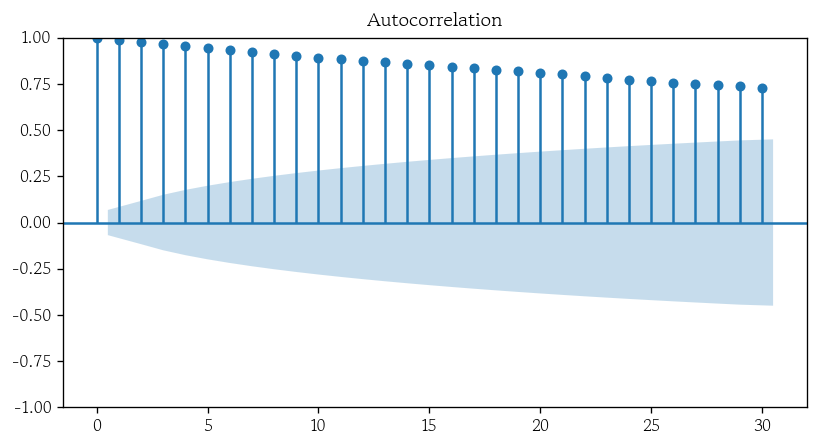

In [36]:
plot_acf(x=df, lags=30);

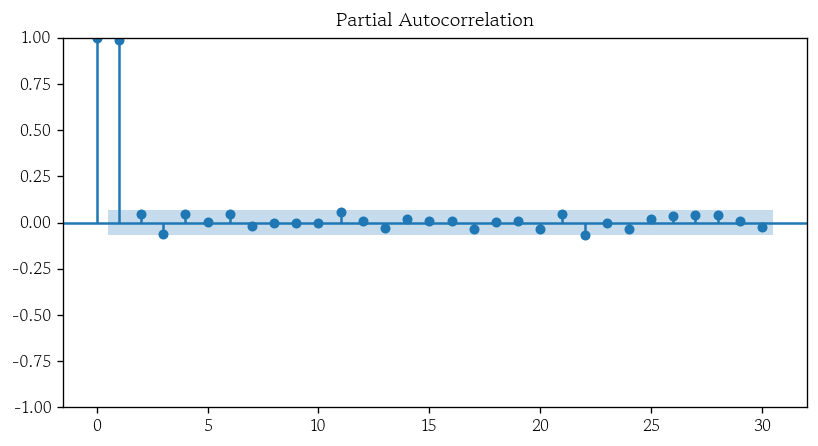

In [37]:
plot_pacf(x=df, lags=30);

In [27]:
rate_diff_1 = df.diff(1).dropna()

In [28]:
rate_diff_1

,rate
2023-12-20,0.0
2023-12-21,-4.0
2023-12-22,3.0
2023-12-23,0.0
2023-12-24,0.0
...,...
2026-03-20,15.5
2026-03-21,0.0
2026-03-22,0.0
2026-03-23,-17.0


In [30]:
os.chdir('../code/time_series')

In [31]:
from plt_rcs import *

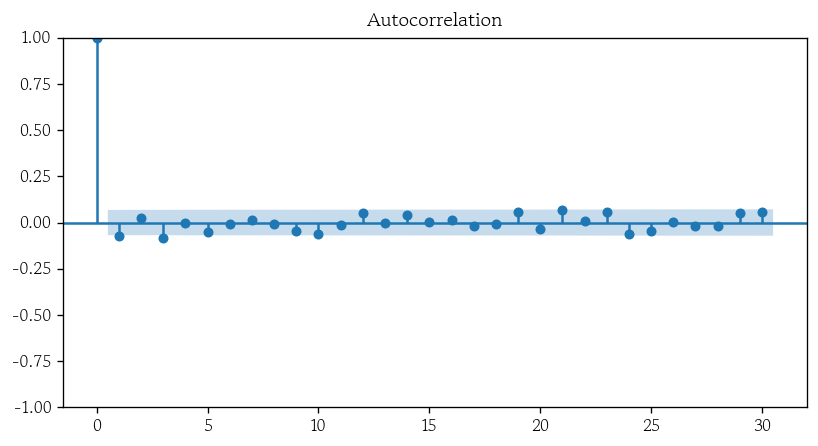

In [34]:
plot_acf(x=rate_diff_1, lags=30);

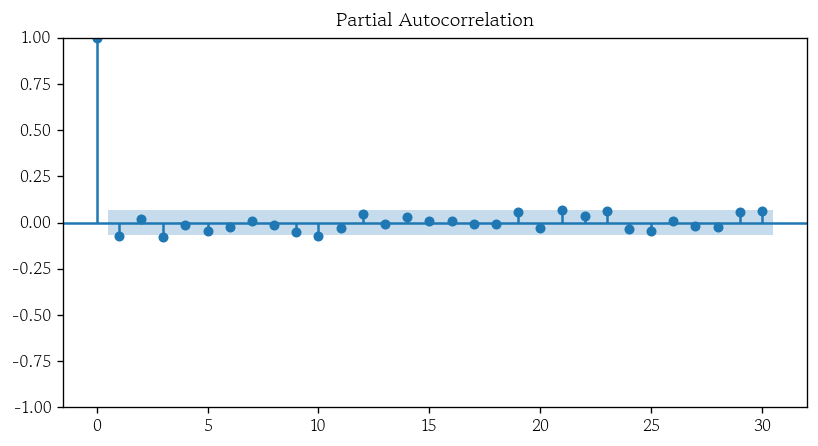

In [35]:
plot_pacf(x=rate_diff_1, lags=30);

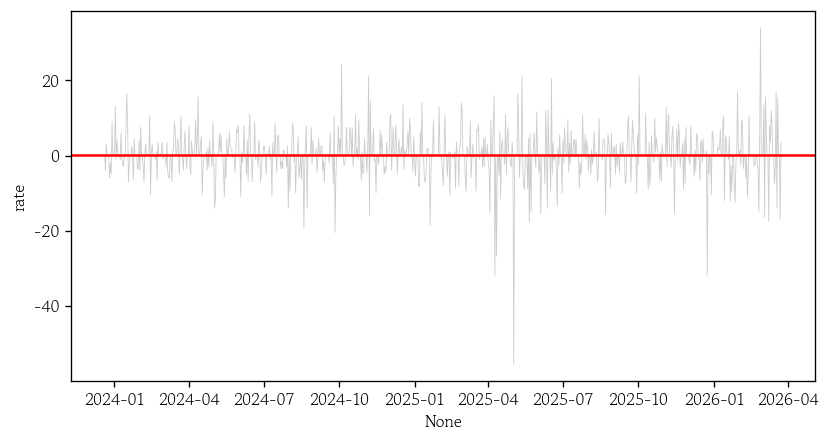

In [33]:
sns.lineplot(x=rate_diff_1.index, y=rate_diff_1['rate'], color='0.8', linewidth=0.5)
plt.axhline(y=rate_diff_1['rate'].mean(), color='red')
plt.show()